### 💳 Credit Card Fraud Detection - Classification 

## ℹ️ About Dataset 

This dataset contains credit card transactions made by European cardholders in the year 2023. It comprises over 550,000 records, and the data has been anonymized to protect the cardholders' identities. The primary objective of this dataset is to facilitate the development of fraud detection algorithms and models to identify potentially fraudulent transactions.

## ❓ Problem we want to solve 

Build machine learning models to detect and prevent credit card fraud by identifying suspicious transactions based on the provided features. (Is fraud or not)

## 🔐 Key Features 

* **id**: Unique identifier for each transaction
* **V1-V28**: Anonymized features representing various transaction attributes (e.g., time, location, etc.)
* **Amount**: The transaction amount
* **Class**: Binary label indicating whether the transaction is fraudulent (1) or not (0)


## 🧠 Algorithms Used
* `KNN` & `SVC`

In [1]:
import pandas as pd

# Read the data 
data = pd.read_csv(r'C:\Users\stfal\OneDrive\Desktop\MachineLearning\Project-1\Lab2_Classification\dataset\creditcard_2023.csv')
data.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [2]:
# Get info 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [3]:
# Check for null values 
data.isnull().sum()

id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

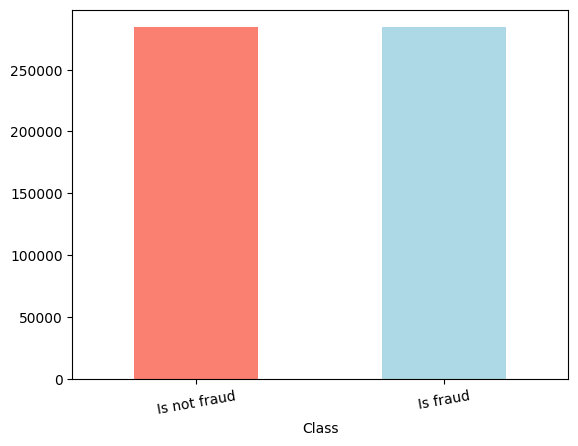

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot difference between number of fraud data and non-fraudulent data
data['Class'].value_counts().plot(kind="bar" , color=["salmon" , "lightblue"]);
plt.xticks(ticks=[1,0] , rotation=10 , labels=['Is fraud' , 'Is not fraud']);
plt.show();

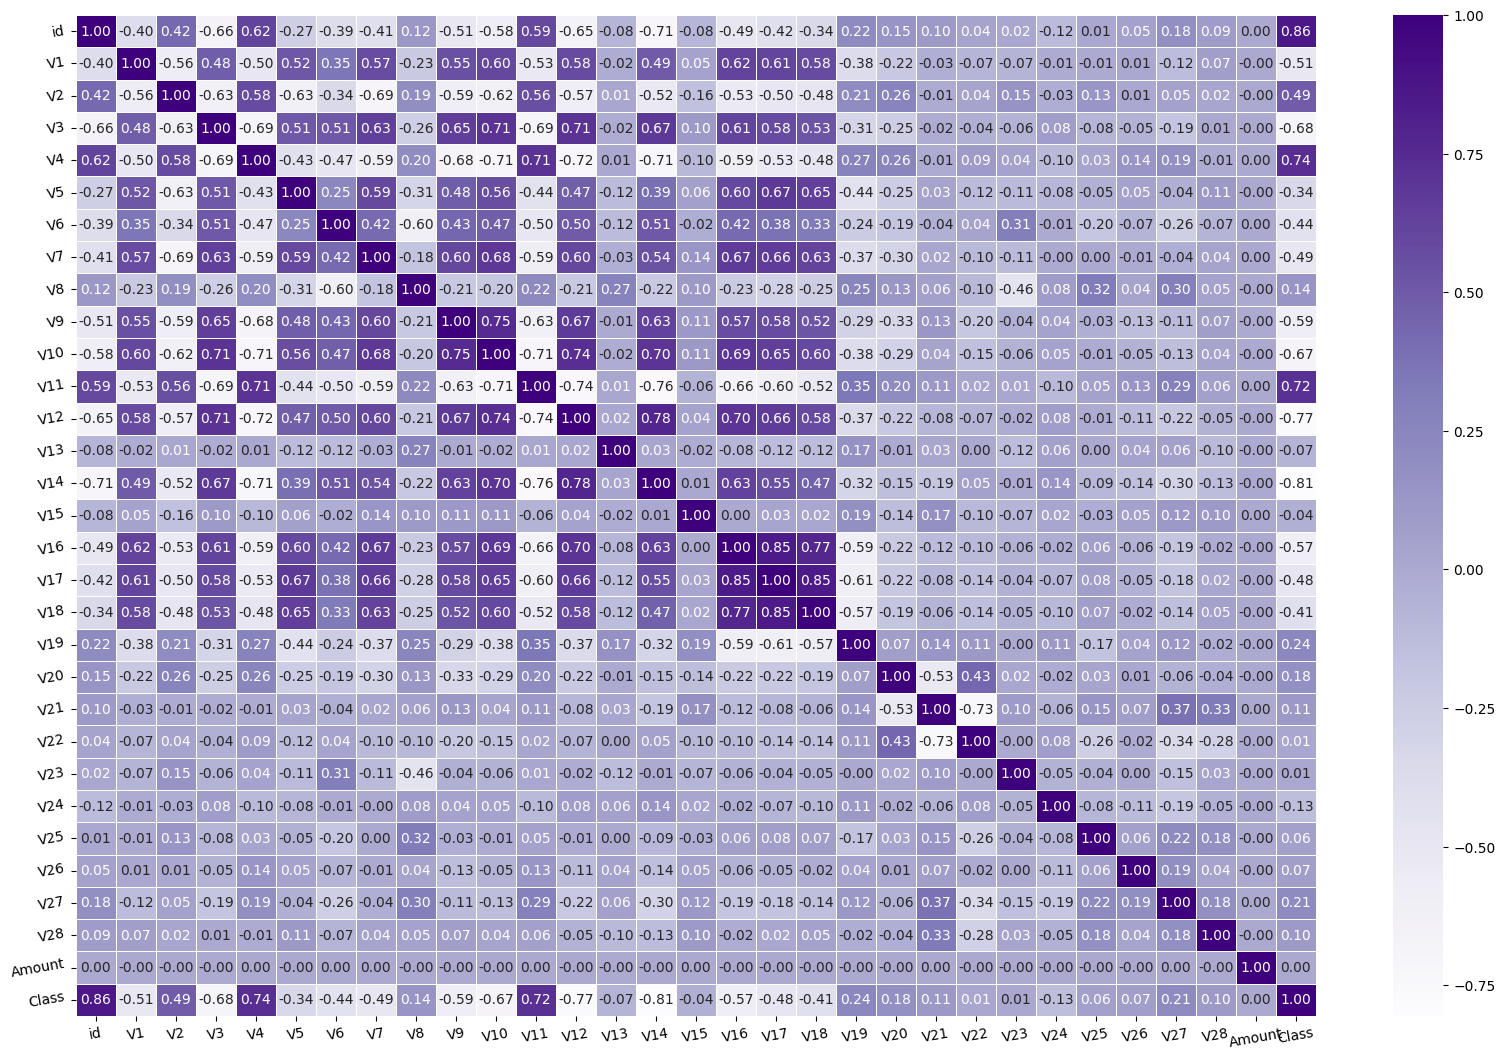

In [5]:
from sklearn.metrics import confusion_matrix , classification_report , precision_score

# Make a coralation matrix
corr_matrix = data.corr()
fig,ax = plt.subplots(figsize=(20,13))
ax = sns.heatmap(corr_matrix , annot=True , linewidths=0.5 , fmt='.2f' , cmap="Purples");
plt.xticks(rotation=10)
plt.yticks(rotation=10)
plt.show();

In [6]:
# Shuffle data 
data = data.sample(frac=1 , random_state=42).reset_index(drop=True)
data = data[:10000]
data.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,437378,0.420468,-0.070194,-0.569266,0.191673,-0.009607,0.426903,-0.356728,0.096143,0.077806,...,0.134969,0.070433,0.047770,-0.851622,0.102876,-0.375436,0.820807,0.665983,8633.18,1
1,504222,-0.238944,0.250929,-0.374408,0.152938,-0.105008,-0.039028,-0.293004,0.133771,-0.591631,...,0.192405,0.289441,-0.255187,-0.817462,0.308284,1.582688,0.574425,0.478489,12299.55,1
2,4794,-0.117796,-0.147961,2.130455,-0.325762,0.325616,0.271351,0.772625,-0.244342,1.240012,...,-0.271739,-0.404654,-0.121235,0.857659,0.541920,0.756534,-0.238177,-0.403038,5215.87,0
3,388411,-0.855315,0.137014,-0.628116,0.613733,-0.643573,-0.664283,-0.880040,0.466586,-1.045508,...,0.405505,0.167560,0.446262,-0.205976,0.492582,0.658619,1.609128,-0.025592,19282.98,1
4,424512,0.257686,0.035247,-0.203112,0.506745,-0.242235,-0.192608,-0.289297,0.044488,-0.396122,...,0.162191,0.165912,-0.181999,0.331451,1.043095,0.029799,0.643273,0.736723,19114.27,1


## Modelling

In [7]:
# Split data into X & y
X = data.drop(["Class"] , axis=1)
y = data["Class"]

In [8]:
from sklearn.model_selection import train_test_split
import numpy as np

# Split data into train and test sets
np.random.seed(42)

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2)
len(X_train) , len(y_train) , len(X_test) , len(y_test)

(8000, 8000, 2000, 2000)

## KNN 

In [9]:
from sklearn.neighbors import KNeighborsClassifier
import time
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=100)
start_time = time.time()
knn.fit(X_train_scaled , y_train)
train_score = knn.score(X_train_scaled , y_train)
end_time = time.time() - start_time

y_pred = knn.predict(X_test_scaled)
precision_score_knn = precision_score(y_test , y_pred)
print(f'Train Time : {end_time * 1000:.2f} ms')
print(f'Train Score : {train_score}')
print(classification_report(y_test , y_pred))

C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\stfal\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\stfal\OneDrive\Desktop\conda_projects\env\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\stfal\OneDrive\Desktop\conda_projects\env\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\stfal\OneDrive\

Train Time : 480.17 ms
Train Score : 0.98
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       981
           1       1.00      0.97      0.98      1019

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



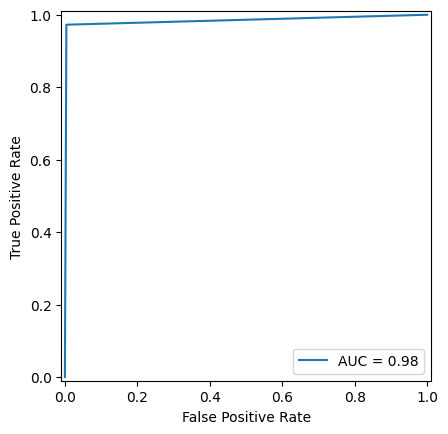

In [10]:
# PLot ROC curve and calculate AUC metric
from sklearn import metrics

fpr , tpr , thresholds = metrics.roc_curve(y_test , y_pred)
roc_auc = metrics.auc(fpr,tpr)
display = metrics.RocCurveDisplay(fpr=fpr , tpr=tpr , roc_auc=roc_auc)
display.plot()
plt.show();

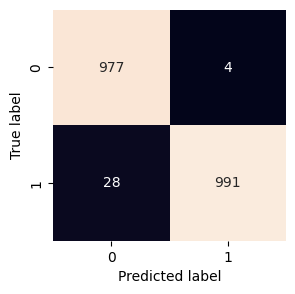

In [11]:
fig,ax = plt.subplots(figsize=(3,3))
ax = sns.heatmap(confusion_matrix(y_test,y_pred),
                     annot=True,
                     fmt='d',
                     cbar=False)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show();    

## SVC

In [12]:
from sklearn.svm import SVC

svc = SVC(kernel='linear' , C=0.0002)
start_time = time.time()
svc.fit(X_train_scaled , y_train)
end_time = start_time - end_time
train_score = svc.score(X_train_scaled , y_train)

y_pred = svc.predict(X_test_scaled)
precision_score_svc = precision_score(y_test , y_pred)
print(f'Train Time : {end_time*1000:.2f}')
print(f'Train Score : {train_score:.2f}')
print(classification_report(y_test , y_pred))

Train Time : 1751400324032.14
Train Score : 0.96
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       981
           1       1.00      0.92      0.96      1019

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



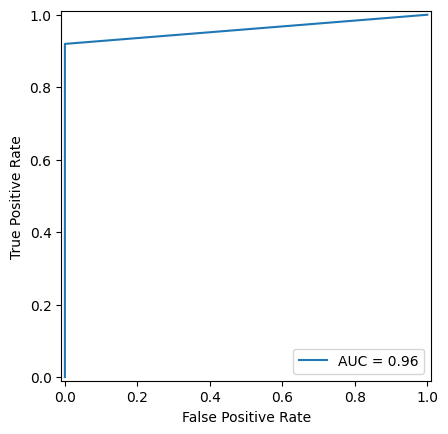

In [13]:
# PLot ROC curve and calculate AUC metric
from sklearn import metrics

fpr , tpr , thresholds = metrics.roc_curve(y_test , y_pred)
roc_auc = metrics.auc(fpr,tpr)
display = metrics.RocCurveDisplay(fpr=fpr , tpr=tpr , roc_auc=roc_auc)
display.plot()
plt.show();

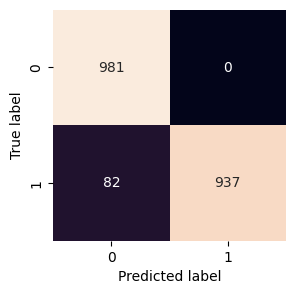

In [14]:
fig,ax = plt.subplots(figsize=(3,3))
ax = sns.heatmap(confusion_matrix(y_test,y_pred),
                     annot=True,
                     fmt='d',
                     cbar=False)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show();    

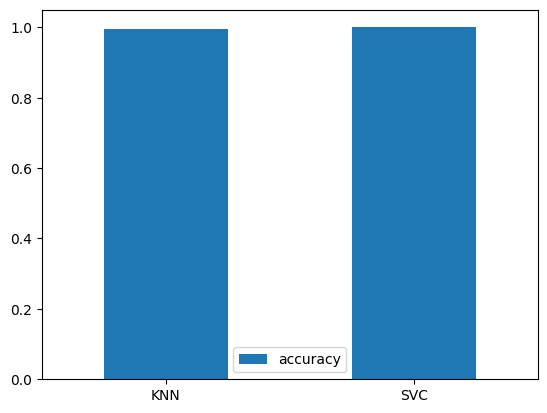

In [ ]:
# Compare KNN & SVC - visualize scores | Overfitting 
model_scores = {'KNN' : precision_score_knn , 'SVC' : precision_score_svc}

model_compare = pd.DataFrame(model_scores , index=["accuracy"])
model_compare.T.plot.bar()
plt.xticks(rotation=0)
plt.show()